# 1. Data Overview

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_parquet("../../data/processed/eda/joined/pickup.parquet")
df.head()

,hour_ts,pulocationid,demand,avg_trip_distance,avg_fare,avg_total_amount,avg_trip_time,avg_tolls_amount,avg_tip_amount,avg_airport_fee,...,zone,service_zone,pickup_date,temperature_mean,precipitation_sum,wind_speed_max,hour,day_of_week,month,is_weekend
0,2025-01-01 00:00:00,60,127,3.997984,21.976457,22.712362,833.902439,0.616220,0.167323,0.000000,...,Crotona Park East,Boro Zone,2025-01-01,7.4,6.1,25.0,0,3,1,0
1,2025-01-01 01:00:00,4,276,5.014888,45.429094,49.649167,1278.905405,0.838696,1.981812,0.000000,...,Alphabet City,Yellow Zone,2025-01-01,7.3,4.8,23.1,1,3,1,0
2,2025-01-01 04:00:00,107,351,5.737057,28.430940,34.494387,1179.772201,2.338974,1.533960,0.120656,...,Gramercy,Yellow Zone,2025-01-01,7.3,4.8,23.1,4,3,1,0
3,2025-01-01 05:00:00,262,53,7.630283,29.394151,37.397170,1141.466667,4.300377,2.327170,0.555556,...,Yorkville East,Yellow Zone,2025-01-01,7.3,4.8,23.1,5,3,1,0
4,2025-01-01 13:00:00,189,81,5.589790,26.987284,28.013704,1163.253165,0.334691,1.879506,0.158228,...,Prospect Heights,Boro Zone,2025-01-01,7.7,5.1,24.7,13,3,1,0


In [23]:
df.shape

(729552, 24)

In [24]:
df.columns


Index(['hour_ts', 'pulocationid', 'demand', 'avg_trip_distance', 'avg_fare',
       'avg_total_amount', 'avg_trip_time', 'avg_tolls_amount',
       'avg_tip_amount', 'avg_airport_fee', 'avg_congestion_surcharge',
       'avg_extra', 'row_fingerprint', 'borough', 'zone', 'service_zone',
       'pickup_date', 'temperature_mean', 'precipitation_sum',
       'wind_speed_max', 'hour', 'day_of_week', 'month', 'is_weekend'],
      dtype='object')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729552 entries, 0 to 729551
Data columns (total 24 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   hour_ts                   729552 non-null  datetime64[ns]
 1   pulocationid              729552 non-null  int32         
 2   demand                    729552 non-null  int64         
 3   avg_trip_distance         729552 non-null  float64       
 4   avg_fare                  729552 non-null  float64       
 5   avg_total_amount          729552 non-null  float64       
 6   avg_trip_time             724631 non-null  float64       
 7   avg_tolls_amount          729552 non-null  float64       
 8   avg_tip_amount            729552 non-null  float64       
 9   avg_airport_fee           724631 non-null  float64       
 10  avg_congestion_surcharge  729348 non-null  float64       
 11  avg_extra                 436927 non-null  float64       
 12  ro

# 2. Missing Values Analysis

In [26]:
print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)


=== MISSING VALUES ===


,missing_count,missing_pct
avg_extra,292625,40.11
service_zone,5259,0.72
temperature_mean,5281,0.72
precipitation_sum,5281,0.72
wind_speed_max,5281,0.72
avg_trip_time,4921,0.67
avg_airport_fee,4921,0.67
zone,2669,0.37
borough,2590,0.36
avg_congestion_surcharge,204,0.03


# 3. Temporal Patterns

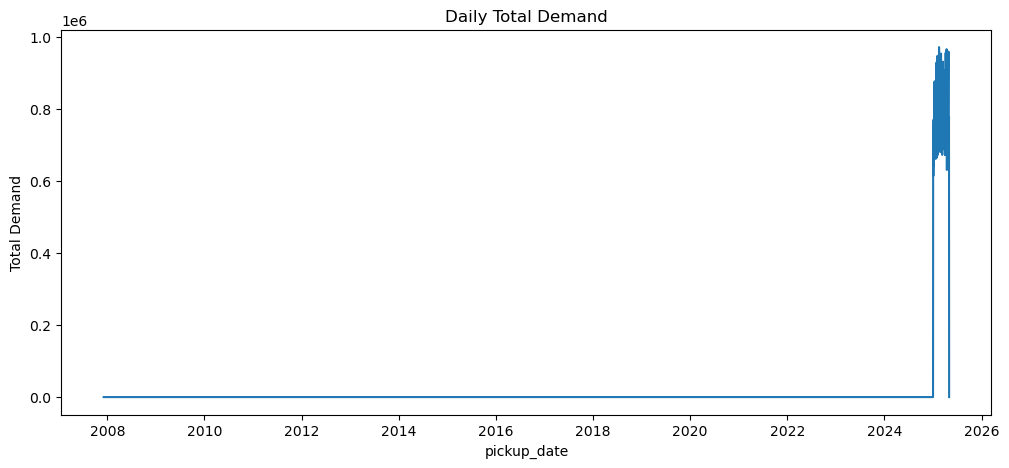

In [27]:
df["hour_ts"] = pd.to_datetime(df["hour_ts"])
df["pickup_date"] = df["hour_ts"].dt.date

daily_demand = df.groupby("pickup_date")["demand"].sum()
daily_demand.plot(figsize=(12, 5), title="Daily Total Demand")
plt.ylabel("Total Demand")
plt.show()

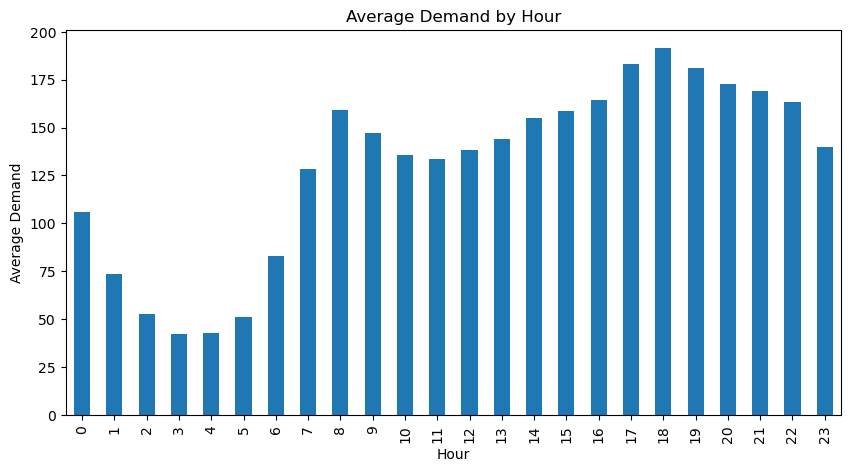

In [28]:
hourly_demand = (
    df.groupby("hour")["demand"]
    .mean()
    .reindex(range(24), fill_value=0)
)

hourly_demand.plot(kind="bar", figsize=(10, 5), title="Average Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Demand")
plt.show()

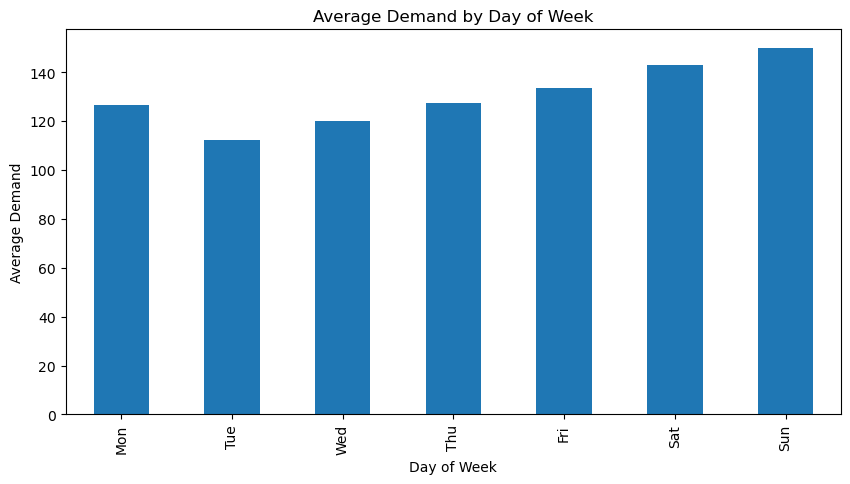

In [29]:
day_map = {
    0: "Mon",
    1: "Tue",
    2: "Wed",
    3: "Thu",
    4: "Fri",
    5: "Sat",
    6: "Sun"
}

daily_pattern = (
    df.groupby("day_of_week")["demand"]
    .mean()
    .reindex(range(7), fill_value=0)
)
daily_pattern.index = daily_pattern.index.map(day_map)

daily_pattern.plot(kind="bar", figsize=(10, 5), title="Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.show()

# 4. Aggregated Trip Characteristics

In [30]:
df["demand"].describe()

count    729552.000000
mean        130.409195
std         162.249424
min           1.000000
25%          30.000000
50%          78.000000
75%         168.000000
max        2364.000000
Name: demand, dtype: float64

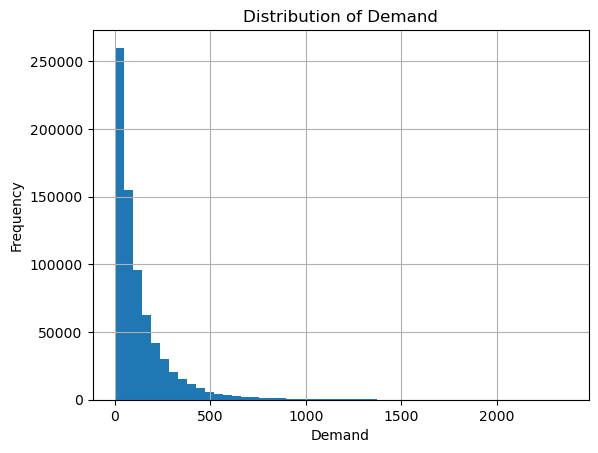

In [31]:
df["demand"].hist(bins=50)
plt.title("Distribution of Demand")
plt.xlabel("Demand")
plt.ylabel("Frequency")
plt.show()

In [32]:
df["avg_trip_distance"].describe()

count    729552.000000
mean          5.459516
std          30.563455
min           0.000000
25%           3.765941
50%           4.499396
75%           5.593813
max       12552.705333
Name: avg_trip_distance, dtype: float64

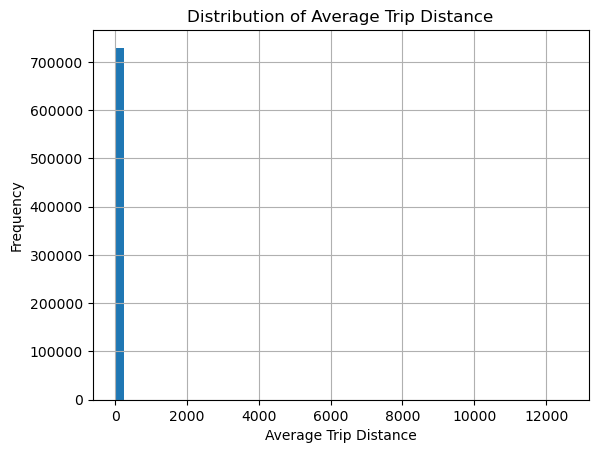

In [33]:
df["avg_trip_distance"].hist(bins=50)
plt.title("Distribution of Average Trip Distance")
plt.xlabel("Average Trip Distance")
plt.ylabel("Frequency")
plt.show()

In [34]:
df["avg_total_amount"].describe()

count    729552.000000
mean         25.812079
std          11.092083
min          -1.660000
25%          19.623102
50%          23.219231
75%          28.912601
max         995.500000
Name: avg_total_amount, dtype: float64

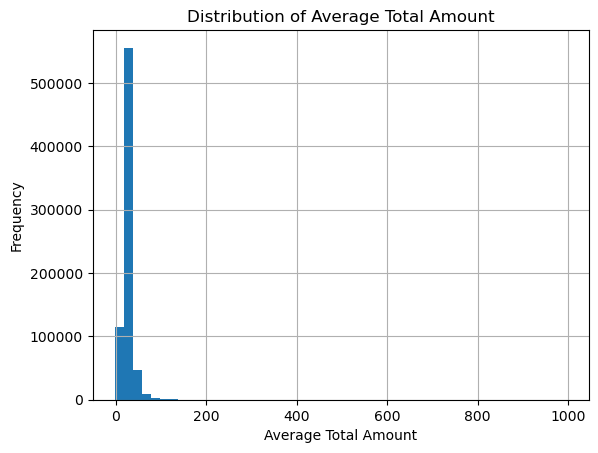

In [35]:
df["avg_total_amount"].hist(bins=50)
plt.title("Distribution of Average Total Amount")
plt.xlabel("Average Total Amount")
plt.ylabel("Frequency")
plt.show()

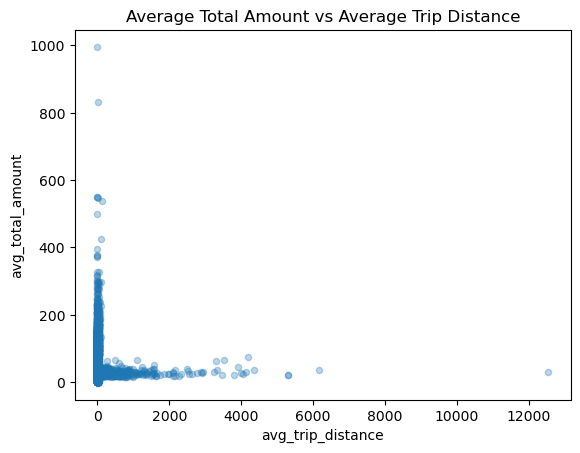

In [36]:
# avg distance vs avg total amount
df.plot.scatter(
    x="avg_trip_distance",
    y="avg_total_amount",
    alpha=0.3,
    title="Average Total Amount vs Average Trip Distance"
)
plt.show()

# 5. Weather Impact

In [37]:
df["precipitation_sum"].describe()

count    724271.000000
mean          2.723674
std           6.093295
min           0.000000
25%           0.000000
50%           0.000000
75%           2.100000
max          38.200000
Name: precipitation_sum, dtype: float64

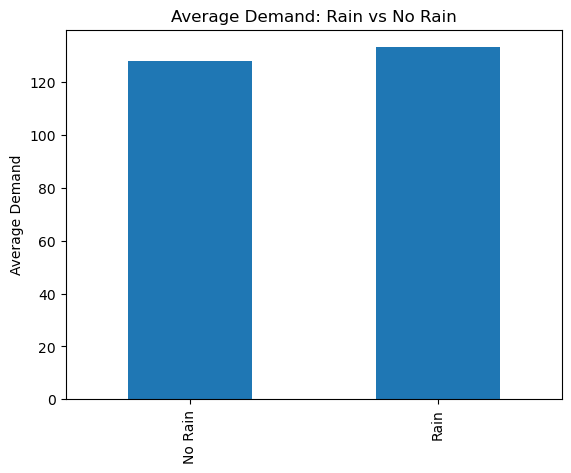

In [38]:
df["is_raining"] = (df["precipitation_sum"] > 0).astype(int)

rain_demand = df.groupby("is_raining")["demand"].mean().reindex([0, 1], fill_value=0)
rain_demand.index = ["No Rain", "Rain"]

rain_demand.plot(kind="bar", title="Average Demand: Rain vs No Rain")
plt.xlabel("")
plt.ylabel("Average Demand")
plt.show()

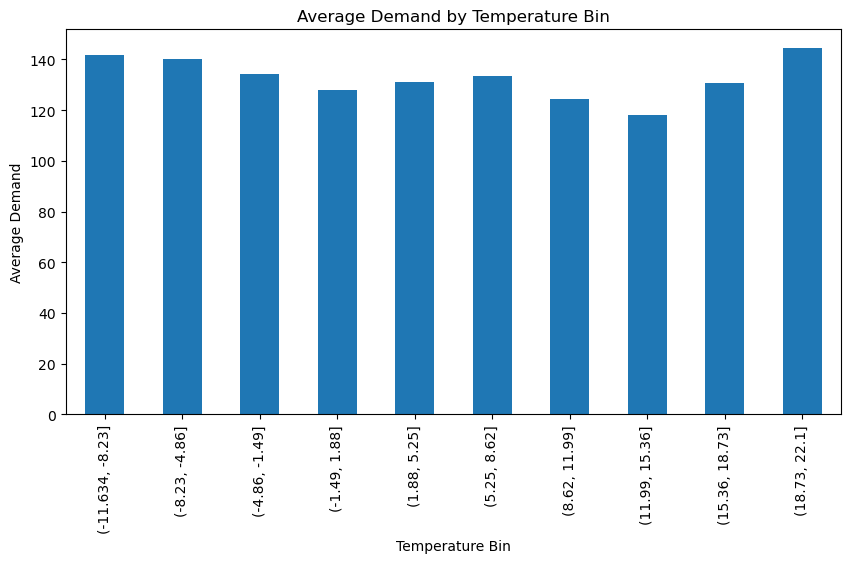

In [39]:
temp_demand = df.dropna(subset=["temperature_mean", "demand"]).copy()
temp_demand["temp_bin"] = pd.cut(temp_demand["temperature_mean"], bins=10)

temp_demand.groupby("temp_bin", observed=False)["demand"].mean().plot(
    kind="bar", figsize=(10, 5), title="Average Demand by Temperature Bin"
)
plt.xlabel("Temperature Bin")
plt.ylabel("Average Demand")
plt.show()

# 6. Location Analysis

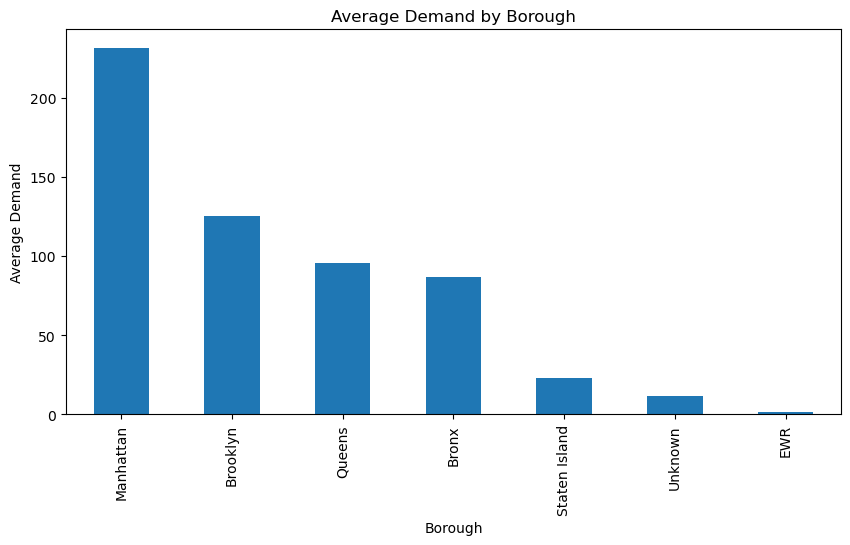

In [40]:
borough_demand = df.groupby("borough")["demand"].mean().sort_values(ascending=False)
borough_demand.plot(kind="bar", figsize=(10, 5), title="Average Demand by Borough")
plt.xlabel("Borough")
plt.ylabel("Average Demand")
plt.show()

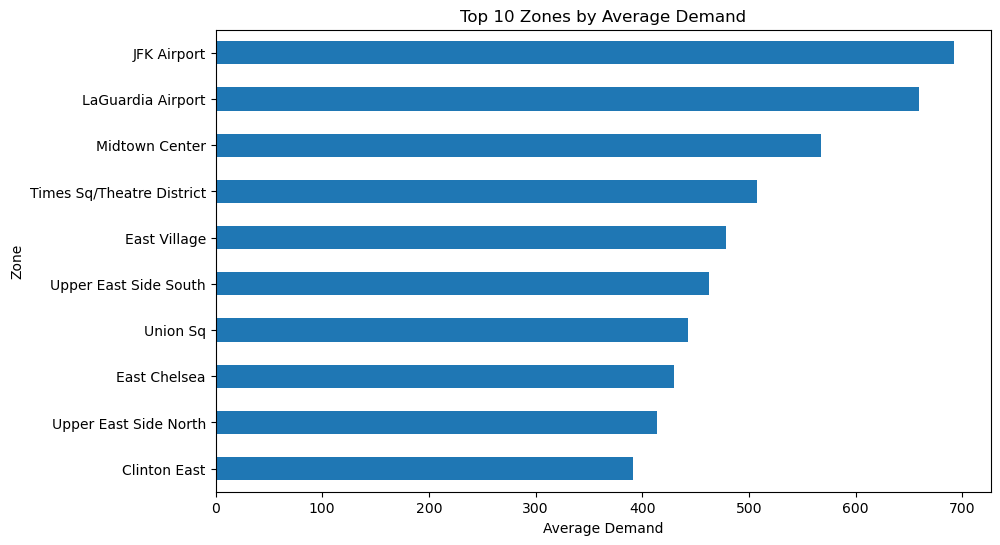

In [41]:
top_zones = (
    df.groupby("zone")["demand"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_zones.sort_values().plot(kind="barh", figsize=(10, 6), title="Top 10 Zones by Average Demand")
plt.xlabel("Average Demand")
plt.ylabel("Zone")
plt.show()

# 7. Correlation Analysis

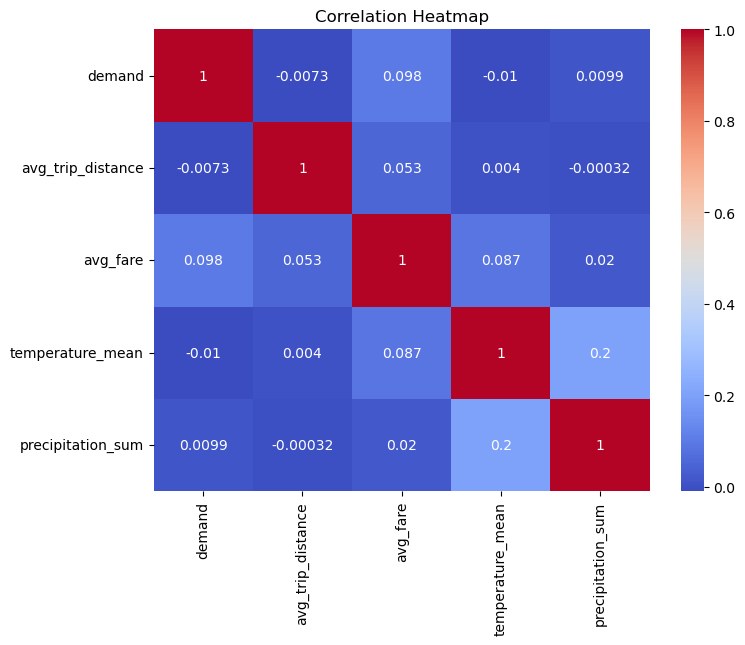

In [42]:
numeric_cols = [
    "demand",
    "avg_trip_distance",
    "avg_fare",
    "temperature_mean",
    "precipitation_sum",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()